<a href="https://colab.research.google.com/github/boba-ueh/ueh_investments1/blob/main/final_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# download the R environment file, where you could change the environment file you build in the previous steps
R_environment_file <- "https://drive.google.com/file/d/1MPTuv_c3-_imaM3FqiQePFoTwZrrAlot/view?usp=sharing"
download.file(R_environment_file,
      destfile="./library.tar.gz")

# unzip the compressed R library file: 'library.tar.gz' into the R library folder
untar("library.tar.gz", exdir = "library")

# change the R library directory into './library'
.libPaths("library")

Warning message in untar("library.tar.gz", exdir = "library"):
“‘/bin/tar -xf 'library.tar.gz' -C 'library'’ returned error code 2”


In [ ]:
install.packages(c("quantmod", "xts", "PerformanceAnalytics", "tseries"))

# --- 0. KHAI BÁO THƯ VIỆN ---
library(googlesheets4)
library(dplyr)
library(ggplot2)
#library(psych)
library(quantmod)
library(xts)
library(PerformanceAnalytics)
library(tseries)
#library(readcsv)

gs4_deauth()
data <- read_sheet(
  "https://docs.google.com/spreadsheets/d/1_4NP-peyr8Eso2EaYF4bdgxVfXL2IzkjyglwT0ya5OA/edit?usp=sharing",
  sheet = 1
)
#head(data)

# Convert time column into Date format
data$time <- as.Date(data$time)

# --- CONVERT WHOLE TABLE TO XTS ---
stock_xts <- xts(
  data[, -1],          # remove time column
  order.by = data$time
)
symbols <- c("TRC", "GVR", "MBB", "SSI", "FPT", "VNINDEX")
for(sym in symbols){
  temp <- stock_xts[, paste0(sym, c(".open", ".high", ".low", ".close"))]
  colnames(temp) <- c("Open", "High", "Low", "Close")
  assign(sym, temp)
}

head(data)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘TTR’, ‘quadprog’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             

time,TRC.open,TRC.high,TRC.low,TRC.close,TRC.volume,GVR.open,GVR.high,GVR.low,GVR.close,⋯,FPT.open,FPT.high,FPT.low,FPT.close,FPT.volume,VNINDEX.open,VNINDEX.high,VNINDEX.low,VNINDEX.close,VNINDEX.volume
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2018-03-21,18.92,18.92,18.69,18.79,64780,12.97,12.97,8.47,9.42,⋯,16.04,16.17,15.96,15.96,999470,1.17,1.17,1.16,1.17,212812970
2018-03-22,18.79,19.05,18.79,18.99,11120,9.51,9.77,8.82,9.42,⋯,15.96,16.07,15.73,15.73,1264760,1.18,1.18,1.17,1.17,215497530
2018-03-23,18.43,18.85,18.43,18.85,3670,9.16,9.16,8.65,9.08,⋯,15.44,15.60,15.18,15.34,2833670,1.15,1.16,1.14,1.15,237107530
2018-03-26,18.59,18.66,18.49,18.66,3590,8.82,9.08,8.82,8.90,⋯,15.34,15.54,15.34,15.49,940840,1.15,1.18,1.15,1.17,175879690
2018-03-27,18.66,18.72,17.44,17.44,38950,9.34,9.51,9.08,9.42,⋯,15.68,15.73,15.44,15.57,993260,1.19,1.19,1.17,1.17,201305790
2018-03-28,18.07,18.46,18.07,18.46,68710,9.42,10.20,9.34,9.94,⋯,15.46,15.54,15.39,15.41,660440,1.17,1.18,1.17,1.17,165131520


#  2/ Technical Analysis — TRC

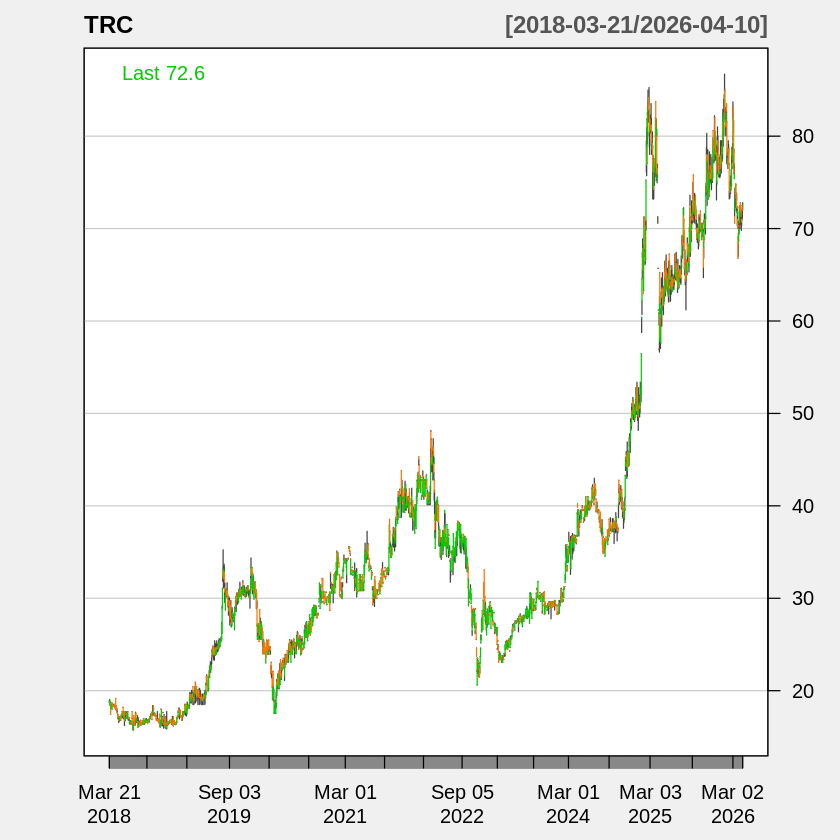

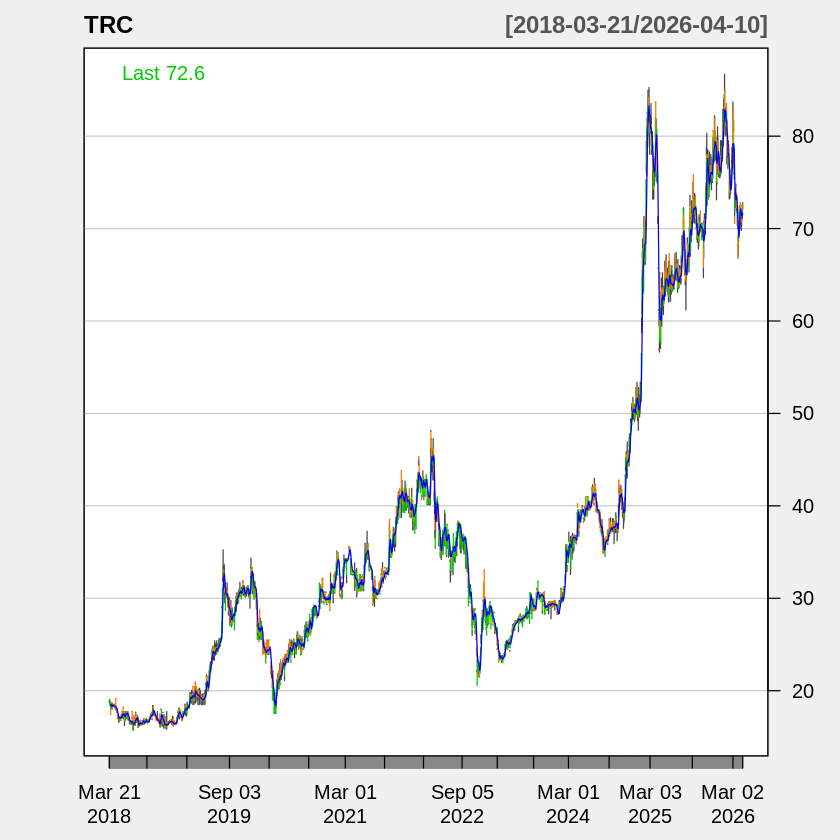

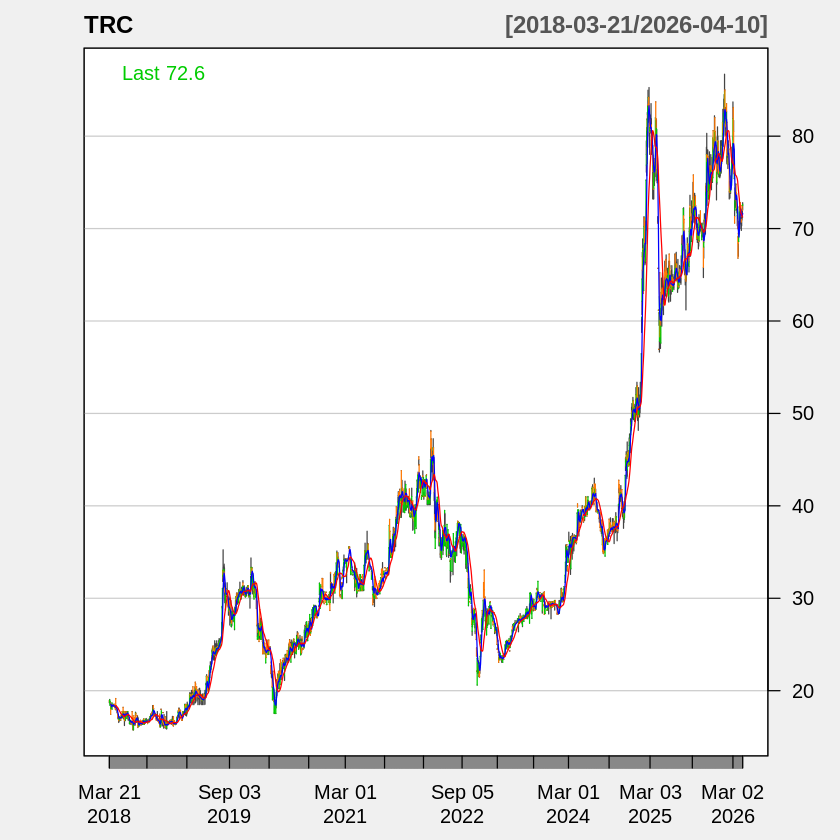

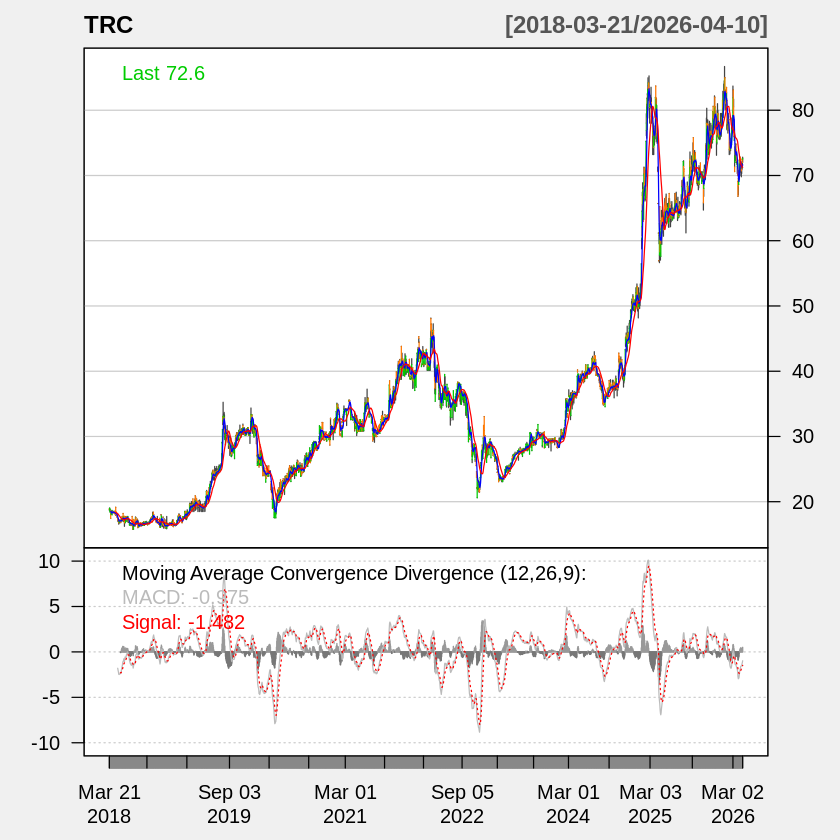

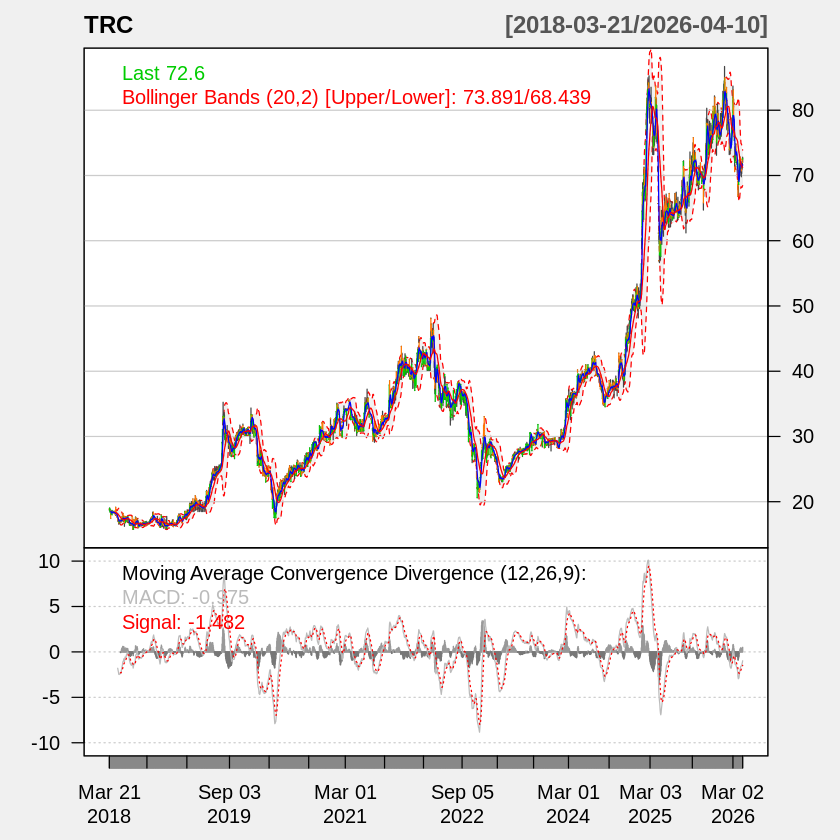

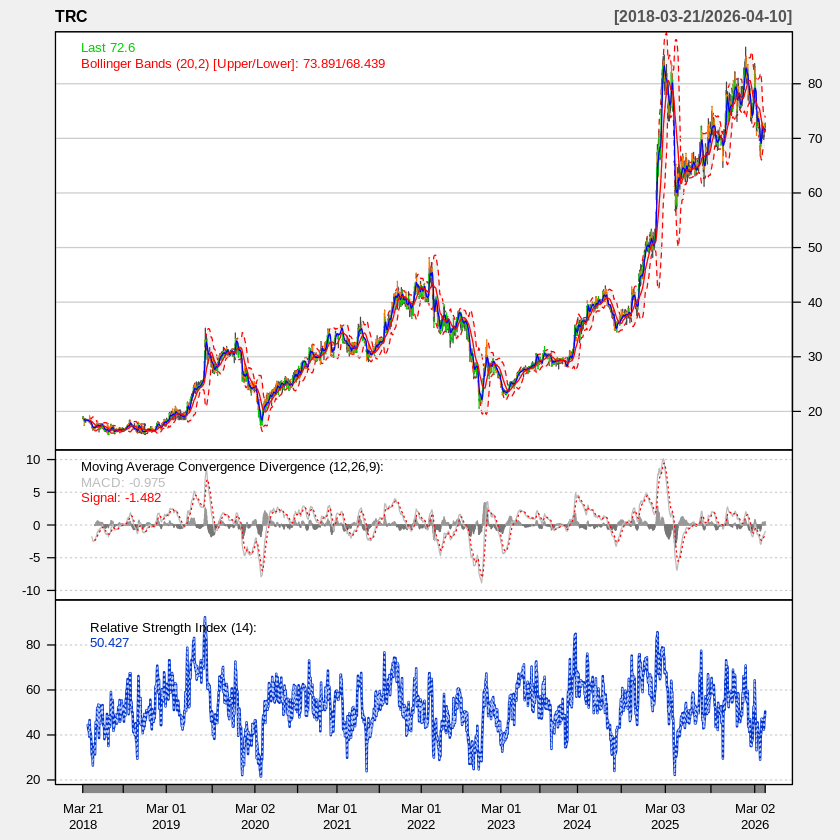

In [ ]:
trc_return <- na.omit(diff(log(Cl(TRC))))

chartSeries(TRC, theme = chartTheme("white"))
addSMA(n=5, col="blue")
addSMA(n=20, col="red")
addMACD(fast=12, slow=26, signal=9)
addBBands(n=20, sd=2)
addRSI(n=14)


In [ ]:
png("technical_analysis.png",
    width = 4000,
    height = 2500,
    res = 400)

chartSeries(last(TRC, "6 months"), theme = chartTheme("white"))

addSMA(n = 5, col = "blue")
addSMA(n = 20, col = "red")

addMACD()
addBBands()
addRSI()

dev.off()

agg_record_88f3d25c472 
                     2

,Mean,SD,Variance,Skewness,Excess_Kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TRC,0.0008387757,0.01797238,0.0003230063,-0.21627673,3.240219
FPT,0.0007162905,0.02330402,0.0005430774,-0.09487858,1.427743
GVR,0.0006747101,0.03058034,0.0009351573,-0.11641775,1.356843
MBB,0.0006308073,0.02086612,0.0004353948,-0.91792341,7.889562
SSI,0.0004365056,0.02652938,0.0007038079,-0.30427919,2.599056


         TRC          FPT          GVR          MBB          SSI 
0.0008387757 0.0007162905 0.0006747101 0.0006308073 0.0004365056 
             TRC          FPT          GVR          MBB          SSI
TRC 3.230063e-04 9.390038e-05 0.0002095925 0.0002051590 0.0002440949
FPT 9.390038e-05 5.430774e-04 0.0002014638 0.0001265309 0.0001334870
GVR 2.095925e-04 2.014638e-04 0.0009351573 0.0002758632 0.0003891861
MBB 2.051590e-04 1.265309e-04 0.0002758632 0.0004353948 0.0003688602
SSI 2.440949e-04 1.334870e-04 0.0003891861 0.0003688602 0.0007038079
          TRC       FPT       GVR       MBB       SSI
TRC 1.0000000 0.2241976 0.3813536 0.5470708 0.5119483
FPT 0.2241976 1.0000000 0.2826987 0.2602100 0.2159141
GVR 0.3813536 0.2826987 1.0000000 0.4323245 0.4797201
MBB 0.5470708 0.2602100 0.4323245 1.0000000 0.6663357
SSI 0.5119483 0.2159141 0.4797201 0.6663357 1.0000000
[1] 0.0006594178
[1] 0.01724728


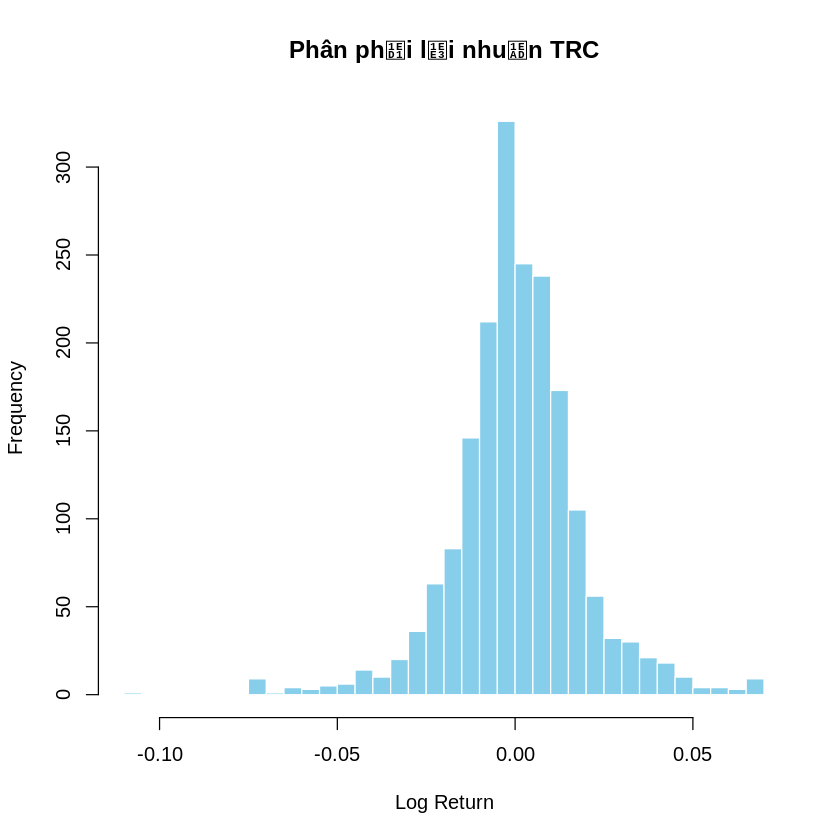

In [ ]:
#Câu 2 – Phân tích danh mục 5 cổ phiếu
# (A) Data & Return
# •Tính log return
# •Thống kê cho từng cổ phiếu:
# o Mean, SD, variance
# o Skewness, kurtosis
# o Vẽ histogram của return
# Nhận xét về tính chuẩn của phân phối return

prices <- merge(
  Cl(FPT),
  Cl(TRC),
  Cl(GVR),
  Cl(MBB),
  Cl(SSI)
)

colnames(prices) <- c("TRC","FPT","GVR","MBB","SSI")
R_all <- na.omit(diff(log(prices)))

mu <- colMeans(R_all)
sd_v <- apply(R_all, 2, sd)
var_v <- apply(R_all, 2, var)
skew_v <- apply(R_all, 2, function(x){
  m <- mean(x)
  s <- sd(x)
  mean((x-m)^3)/(s^3)
})
ex_kurt_v <- apply(R_all, 2, function(x){
  m <- mean(x)
  s <- sd(x)
  mean((x-m)^4)/(s^4) - 3
})

stats_table <- data.frame(
  Mean=mu,
  SD=sd_v,
  Variance=var_v,
  Skewness=skew_v,
  Excess_Kurtosis=ex_kurt_v
)

hist(
  R_all[, "TRC"],
  breaks=50,
  main="Phân phối lợi nhuận TRC",
  col="skyblue",
  xlab="Log Return",
  border="white"
)

stats_table

#(B) Lý thuyết danh mục (Markowitz)
# 1. Tính:
# o Expected return vector 𝐸(𝑅)
# o Covariance matrix Σ
# o Correlation matrix

ER_vector <- mu
Sigma <- cov(R_all)
Corr_mat <- cor(R_all)

print(ER_vector)
print(Sigma)
print(Corr_mat)

# 2. Chọn 2 cổ phiếu trong đó. Xây dựng danh mục:
# o Portfolio với tỷ trọng bằng nhau
# o Tìm tỷ trọng đầu tư để có Minimum Variance Portfolio (MVP)


v1 <- Sigma["TRC","TRC"]
v2 <- Sigma["MBB","MBB"]
c12 <- Sigma["TRC","MBB"]

w_fpt_mvp <- (v2-c12)/(v1+v2-2*c12)
w_trc_mvp <- 1-w_fpt_mvp

# 3. Với tỷ trọng bằng nhau, hãy tính lợi nhuận kỳ vọng và rủi ro (sigma) cho danh mục gồm 5 cổ phiếu trên.

w5 <- rep(0.2, 5)

ERP5 <- sum(w5*mu)

SDP5 <- sqrt(
  as.numeric(
    t(w5)%*%Sigma%*%w5
  )
)

print(ERP5)
print(SDP5)
# 4. Liên hệ thực tiễn và nhận xét về kết quả.

,alpha,beta
TRC,6e-04,0.8370
FPT,6e-04,0.5118
GVR,4e-04,1.1808
MBB,4e-04,1.1363
SSI,2e-04,1.3557


       TRC        FPT        GVR        MBB        SSI 
0.04896434 0.04023300 0.05819588 0.05700014 0.06289145 


,Real,CAPM
TRC,0.2097,0.0490
FPT,0.1791,0.0402
GVR,0.1687,0.0582
MBB,0.1577,0.0570
SSI,0.1091,0.0629


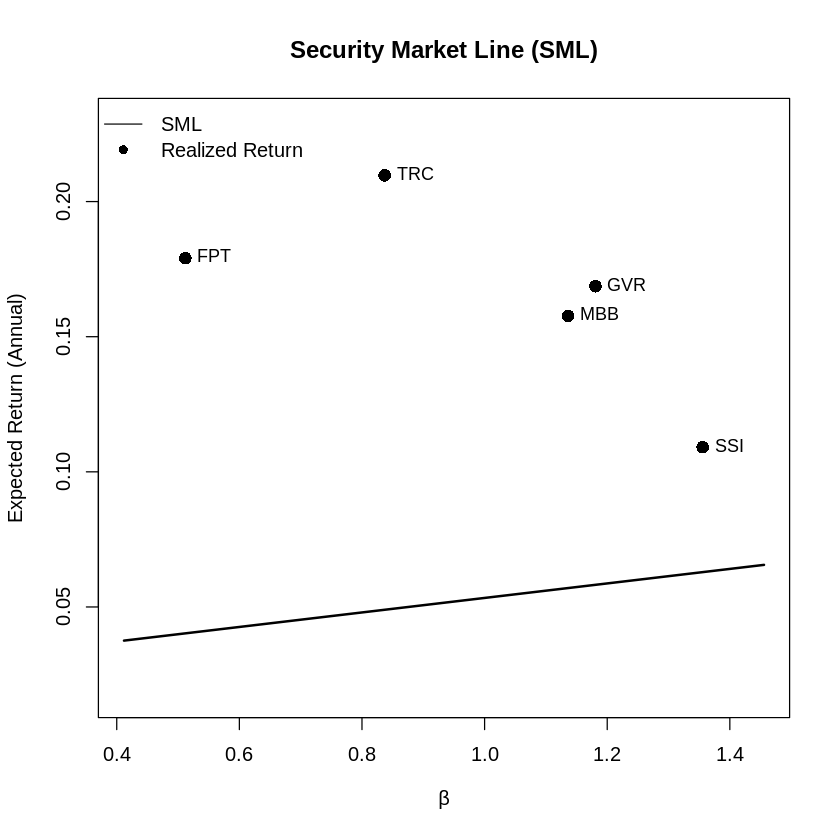

In [ ]:
# ==========================================
# CAPM REGRESSION + SECURITY MARKET LINE
# ==========================================
# --- 1. Risk Free Rate ---
rf_annual <- 0.02649
rf_daily <- rf_annual / 250
# --- 2. Market Return ---
Rm <- na.omit(diff(log(Cl(VNINDEX))))
# --- 3. Excess Returns ---
Ri_excess <- R_all - rf_daily
Rm_excess <- Rm - rf_daily
# ==========================================
# 4. Estimate Beta + Alpha for Each Stock
# ==========================================
beta_lm <- apply(Ri_excess, 2, function(x){
  coef(lm(x ~ Rm_excess))[2]
})
alpha_lm <- apply(Ri_excess, 2, function(x){
  coef(lm(x ~ Rm_excess))[1]
})
round(
  cbind(alpha = alpha_lm, beta = beta_lm),
  4
)
# ==========================================
# 5. CAPM Expected Return
# ==========================================
ERm <- mean(as.numeric(Rm)) * 250
ERP <- ERm - rf_annual
ER_capm <- rf_annual + beta_lm * ERP
print(ER_capm)
# ==========================================
# 6. Realized Return Comparison
# ==========================================
ER_real <- colMeans(R_all) * 250
round(
  cbind(
    Real = ER_real,
    CAPM = ER_capm
  ),
  4
)
# ==========================================
# 7. Prepare Plot Data
# ==========================================
assets <- colnames(R_all)
beta_all <- as.numeric(beta_lm)
ER_real_all <- as.numeric(ER_real)
# ==========================================
# 8. SML Line Coordinates
# ==========================================
x_line <- seq(
  min(beta_all) - 0.1,
  max(beta_all) + 0.1,
  length.out = 200
)
y_line <- rf_annual + x_line * ERP
# ==========================================
# 9. Plot Security Market Line
# ==========================================

plot(
  x_line,
  y_line,
  type = "l",
  lwd = 2,
  xlim = range(beta_all) + c(-0.1, 0.1),
  ylim = range(c(ER_real_all, y_line)) + c(-0.02, 0.02),
  xlab = expression(beta),
  ylab = "Expected Return (Annual)",
  main = "Security Market Line (SML)"
)
# Plot Realized Return Points
points(
  beta_all,
  ER_real_all,
  pch = 16,
  cex = 1.4
)
# Labels
text(
  beta_all,
  ER_real_all,
  labels = assets,
  pos = 4,
  cex = 0.9
)
# Legend
legend(
  "topleft",
  legend = c("SML", "Realized Return"),
  lty = c(1, NA),
  pch = c(NA, 16),
  bty = "n"
)



In [ ]:
# ==========================================
# FULL OUTPUT BLOCK FOR ANALYSIS (ALL METRICS)
# ==========================================

# ===== 1. BASIC MARKET + CAPM INPUTS =====
ERm <- mean(as.numeric(Rm)) * 250
ERP <- ERm - rf_annual

cat("===== MARKET =====\n")
cat("ERm (Market Return):", ERm, "\n")
cat("ERP (Market Risk Premium):", ERP, "\n\n")

# ===== 2. BETA =====
cat("===== BETA =====\n")
print(beta_all)
cat("\n")

# ===== 3. ALPHA + BETA TABLE =====
cat("===== ALPHA & BETA =====\n")
print(round(
  cbind(alpha = alpha_lm, beta = beta_lm),
  4
))
cat("\n")

# ===== 4. REALIZED vs CAPM RETURN =====
cat("===== REALIZED vs CAPM =====\n")
print(round(
  cbind(
    Real = ER_real,
    CAPM = ER_capm
  ),
  4
))
cat("\n")

# ===== 5. ALPHA ONLY =====
cat("===== ALPHA =====\n")
print(round(alpha_lm, 4))
cat("\n")

# ===== 6. REGRESSION SUMMARY (FIRST STOCK) =====
cat("===== REGRESSION SUMMARY (TRC) =====\n")
print(summary(lm(Ri_excess[,1] ~ Rm_excess)))
cat("\n")

# ===== 7. CORRELATION MATRIX =====
cat("===== CORRELATION MATRIX =====\n")
print(cor(R_all))
cat("\n")

# ===== 8. ANNUALIZED VOLATILITY =====
cat("===== VOLATILITY (ANNUALIZED) =====\n")
print(sd_v * sqrt(250))
cat("\n")

# ===== 9. DESCRIPTIVE STATISTICS =====
cat("===== DESCRIPTIVE STATISTICS =====\n")
print(stats_table)
cat("\n")

# ===== 10. PORTFOLIO (EQUAL WEIGHT) =====
cat("===== PORTFOLIO (EQUAL WEIGHT) =====\n")
cat("Expected Return:", ERP5, "\n")
cat("Risk (Std Dev):", SDP5, "\n\n")

# ===== 11. MVP (2-ASSET) =====
cat("===== MVP (TRC & SSI) =====\n")
cat("Weight TRC:", w_trc_mvp, "\n")
cat("Weight SSI:", w_fpt_mvp, "\n\n")

# ===== 12. COVARIANCE MATRIX =====
cat("===== COVARIANCE MATRIX =====\n")
print(Sigma)
cat("\n")

# ===== 13. EXPECTED RETURN VECTOR =====
cat("===== EXPECTED RETURN VECTOR =====\n")
print(ER_vector)
cat("\n")

# ==========================================
# SHARPE RATIO
# ==========================================

sharpe_ratio <- (ER_real - rf_annual) / (sd_v * sqrt(250))

cat("===== SHARPE RATIO =====\n")
print(round(sharpe_ratio, 4))
cat("\n")

# ==========================================
# MISPRICING (REAL - CAPM)
# ==========================================

mispricing <- ER_real - ER_capm

cat("===== MISPRICING =====\n")
print(round(
  cbind(
    Real = ER_real,
    CAPM = ER_capm,
    Mispricing = mispricing
  ),
  4
))
cat("\n")

# ==========================================
# ALPHA SIGNIFICANCE TEST
# ==========================================

alpha_test <- lapply(colnames(Ri_excess), function(stock){
  model <- lm(Ri_excess[,stock] ~ Rm_excess)
  coef(summary(model))[1,]   # intercept only
})

alpha_test <- do.call(rbind, alpha_test)
rownames(alpha_test) <- colnames(Ri_excess)

cat("===== ALPHA SIGNIFICANCE =====\n")
print(round(alpha_test, 4))
cat("\n")

# ==========================================
# R-SQUARED (ALL STOCKS)
# ==========================================

R2_all <- sapply(colnames(Ri_excess), function(stock){
  summary(lm(Ri_excess[,stock] ~ Rm_excess))$r.squared
})

cat("===== R-SQUARED =====\n")
print(round(R2_all, 4))
cat("\n")

# ==========================================
# BETA (COVARIANCE METHOD)
# ==========================================

var_m <- var(Rm_excess)

beta_cov <- apply(Ri_excess, 2, function(x){
  cov(x, Rm_excess) / var_m
})

cat("===== BETA (COVARIANCE) =====\n")
print(round(beta_cov, 4))
cat("\n")

# ==========================================
# DIVERSIFICATION EFFECT
# ==========================================

avg_sd <- mean(sd_v * sqrt(250))
portfolio_sd <- SDP5 * sqrt(250)

cat("===== DIVERSIFICATION =====\n")
cat("Average Individual Risk:", round(avg_sd,4), "\n")
cat("Portfolio Risk:", round(portfolio_sd,4), "\n\n")



===== MARKET =====
ERm (Market Return): 0.05334023 
ERP (Market Risk Premium): 0.02685023 

===== BETA =====
[1] 0.8370261 0.5118394 1.1808421 1.1363084 1.3557221

===== ALPHA & BETA =====
    alpha   beta
TRC 6e-04 0.8370
FPT 6e-04 0.5118
GVR 4e-04 1.1808
MBB 4e-04 1.1363
SSI 2e-04 1.3557

===== REALIZED vs CAPM =====
      Real   CAPM
TRC 0.2097 0.0490
FPT 0.1791 0.0402
GVR 0.1687 0.0582
MBB 0.1577 0.0570
SSI 0.1091 0.0629

===== ALPHA =====
  TRC   FPT   GVR   MBB   SSI 
6e-04 6e-04 4e-04 4e-04 2e-04 

===== REGRESSION SUMMARY (TRC) =====

Call:
lm(formula = Ri_excess[, 1] ~ Rm_excess)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.059385 -0.008413 -0.000688  0.006859  0.070019 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0006429  0.0003169   2.029   0.0426 *  
Rm_excess   0.8370261  0.0229594  36.457   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01377 on 1885 degr

In [ ]:
print(summary(lm(Ri_excess[,2] ~ Rm_excess)))


Call:
lm(formula = Ri_excess[, 2] ~ Rm_excess)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.077205 -0.010440 -0.000607  0.010927  0.071761 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0005554  0.0005114   1.086    0.278    
Rm_excess   0.5118394  0.0370433  13.817   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02221 on 1885 degrees of freedom
Multiple R-squared:  0.09197,	Adjusted R-squared:  0.09149 
F-statistic: 190.9 on 1 and 1885 DF,  p-value: < 2.2e-16

